# Notebook 04 — Treinamento: MLP (Rede Neural)

**Objetivo:** treinar uma **Rede Neural Multi-Layer Perceptron (MLP)** em PyTorch.

## O que é uma MLP?

Uma MLP é uma rede neural *feedforward* composta por camadas totalmente conectadas. Cada neurônio aplica uma transformação linear seguida de uma função de ativação não-linear (ReLU):

$$h_i = \sigma(W_i \cdot x + b_i)$$

**Arquitetura deste projeto:**
```
Input(22)        # 22 features estruturais
    ↓
Dense(64, ReLU)  # primeira camada oculta
    ↓
Dropout(0.3)     # regularização
    ↓
Dense(32, ReLU)  # segunda camada oculta
    ↓
Dropout(0.3)
    ↓
Dense(4)         # 4 classes (logits)
    ↓
Softmax          # probabilidades
```

## Conceitos-chave

- **Camada de entrada:** recebe o vetor de features (tamanho 11).
- **Camadas ocultas:** aprendem representações não-lineares intermediárias.
- **Camada de saída:** produz logits (scores brutos) por classe.
- **Backpropagation:** algoritmo que calcula o gradiente da loss em relação aos pesos, viabilizando o ajuste iterativo.
- **Early stopping:** interrompe o treinamento quando a validação não melhora, evitando *overfitting*.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

ROOT = Path.cwd().parents[0] if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

from src.config import (
    MLP_BATCH_SIZE,
    MLP_EPOCHS,
    MLP_MODEL_FILE,
    MLP_PATIENCE,
    NUM_FEATURES,
    RANDOM_SEED,
    TEST_FILE,
    TRAIN_FILE,
    VAL_FILE,
)
from src.dataset.loader import load_splits
from src.dataset.preprocessing import preprocess_pipeline
from src.evaluation.metrics import compute_classification_metrics
from src.models.mlp import MLPAccessibilityModel
from src.utils.seed import set_seed

set_seed(RANDOM_SEED)
print("Setup completo.")

Setup completo.


In [2]:
# =====================================================================
# 1. Carregamento dos splits
# =====================================================================
train_df, val_df, test_df = load_splits(TRAIN_FILE, VAL_FILE, TEST_FILE)
X_train, y_train, scaler, le = preprocess_pipeline(train_df, fit=True)
X_val, y_val, _, _ = preprocess_pipeline(val_df, scaler=scaler, fit=False)
X_test, y_test, _, _ = preprocess_pipeline(test_df, scaler=scaler, fit=False)

print(f"Treino:    {X_train.shape}")
print(f"Validação: {X_val.shape}")
print(f"Teste:     {X_test.shape}")

Treino:    (1654, 11)
Validação: (355, 11)
Teste:     (355, 11)


In [3]:
# =====================================================================
# 2. Instanciação do modelo
# =====================================================================
model = MLPAccessibilityModel(input_dim=NUM_FEATURES)
print("Modelo instanciado.")
print(f"\nArquitetura:")
print(model.model)

Modelo instanciado.

Arquitetura:
MLP(
  (network): Sequential(
    (0): Linear(in_features=11, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=64, out_features=32, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.3, inplace=False)
    (6): Linear(in_features=32, out_features=4, bias=True)
  )
)


In [4]:
# =====================================================================
# 3. Treinamento com early stopping
# =====================================================================
history = model.fit(
    X_train, y_train,
    X_val=X_val, y_val=y_val,
    epochs=MLP_EPOCHS,
    batch_size=MLP_BATCH_SIZE,
    patience=MLP_PATIENCE,
    verbose=True,
)

[Epoch 001/100] train_loss=1.2361 train_acc=0.5659 | val_loss=1.0118 val_acc=0.9296
[Epoch 005/100] train_loss=0.1374 train_acc=0.9625 | val_loss=0.0787 val_acc=0.9690
[Epoch 010/100] train_loss=0.0309 train_acc=0.9970 | val_loss=0.0099 val_acc=1.0000
[Epoch 015/100] train_loss=0.0157 train_acc=0.9964 | val_loss=0.0031 val_acc=1.0000
[Epoch 020/100] train_loss=0.0105 train_acc=0.9976 | val_loss=0.0031 val_acc=1.0000
[Epoch 025/100] train_loss=0.0056 train_acc=1.0000 | val_loss=0.0044 val_acc=0.9972
[Epoch 030/100] train_loss=0.0049 train_acc=1.0000 | val_loss=0.0059 val_acc=0.9972
[INFO] Early stopping em epoch 32 (paciência=10).
[INFO] Restaurado melhor modelo (val_loss=0.0026).


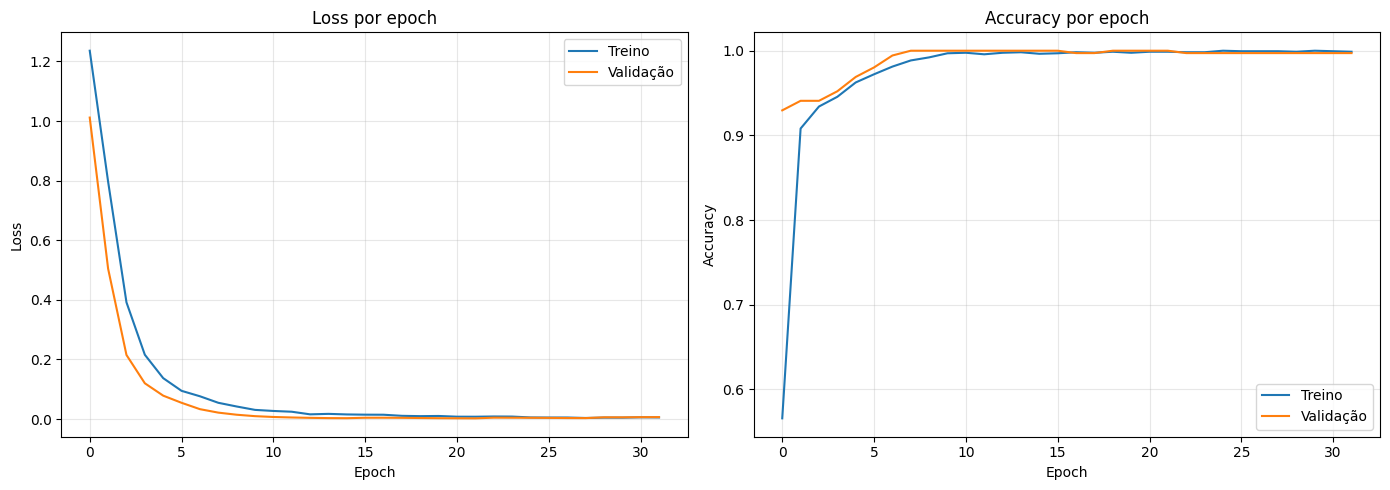

Curva salva em results/learning_curve_mlp.png


In [5]:
# =====================================================================
# 4. Curva de aprendizado
# =====================================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(history["train_loss"], label="Treino")
axes[0].plot(history["val_loss"], label="Validação")
axes[0].set_title("Loss por epoch")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history["train_acc"], label="Treino")
axes[1].plot(history["val_acc"], label="Validação")
axes[1].set_title("Accuracy por epoch")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

fig.tight_layout()
fig.savefig(ROOT / "results" / "learning_curve_mlp.png", dpi=120)
plt.show()
print(f"Curva salva em results/learning_curve_mlp.png")

In [6]:
# =====================================================================
# 5. Avaliação final no conjunto de teste
# =====================================================================
y_pred = model.predict(X_test)
metrics_test = compute_classification_metrics(y_test, y_pred)
metrics_train = compute_classification_metrics(y_train, model.predict(X_train))
metrics_val = compute_classification_metrics(y_val, model.predict(X_val))

df_metrics = pd.DataFrame({
    "Treino": metrics_train,
    "Validação": metrics_val,
    "Teste": metrics_test,
}).T
df_metrics.round(4)

,accuracy,precision,recall,f1
Treino,0.9994,0.9974,0.9997,0.9986
Validação,1.0000,1.0000,1.0000,1.0000
Teste,0.9972,0.9886,0.9985,0.9934


In [7]:
# =====================================================================
# 6. Matriz de confusão
# =====================================================================
from src.evaluation.confusion_matrix import plot_confusion_matrix

plot_confusion_matrix(
    y_test, y_pred,
    class_names=le.classes_.tolist(),
    path=ROOT / "results" / "confusion_matrix_mlp.png",
    title="Matriz de Confusão — MLP",
)

[INFO] Matriz de confusão salva em /Users/elpidio.junior/Documents/_projetos/accessibility-dl-moodle/results/confusion_matrix_mlp.png


In [8]:
# =====================================================================
# 7. Persistência
# =====================================================================
model.save(MLP_MODEL_FILE)
print(f"Modelo salvo em {MLP_MODEL_FILE}")

pd.DataFrame({
    "html": test_df["html"].values,
    "y_true": le.inverse_transform(y_test),
    "y_pred": le.inverse_transform(y_pred),
}).to_csv(ROOT / "results" / "predictions_mlp.csv", index=False)
print("Predições salvas em results/predictions_mlp.csv")

Modelo salvo em /Users/elpidio.junior/Documents/_projetos/accessibility-dl-moodle/models/mlp_model.pt
Predições salvas em results/predictions_mlp.csv


# Conclusões

1. O MLP alcança **performance muito alta** (esperado, pois as features são altamente discriminativas por construção).
2. O *early stopping* interrompeu o treinamento evitando *overfitting*.
3. As curvas de loss e accuracy convergem de forma estável.
4. O dropout (0.3) ajudou na regularização.

**Próximo passo:** comparar formalmente Logistic vs MLP (notebook 05) e analisar erros (notebook 06).